In [25]:
using LowLevelFEM

In [26]:
openGeometry("plate_with_hole.geo")

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading 'plate_with_hole.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 70%] Meshing curve 4 (Line)
Info    : [ 90%] Meshing curve 5 (Circle)
Info    : Done meshing 1D (Wall 0.00143764s, CPU 0.001428s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.20137s, CPU 0.196872s)
Info    : Meshing order 5 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 5
Info    : [ 20%] Meshing curve 2 order 5
Info    : [ 40%] Meshing curve 3 order 5
Info    : [ 60%] Meshing curve 4 order 5
Info    : [ 70%] Meshing curve 5 order 5
Info    : [ 90%] Meshing surface 1 order 5
Info    : Surface mesh: worst distortion = 0.984948 (0 elements in ]0, 0.2]); worst gamma = 0.621914
Info    : Done meshing order 5 (Wall 0.0990015s, CPU 

In [27]:
openPreProcessor()

-------------------------------------------------------
Version       : 4.15.0-git
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 19700101
Build host    : amdci7.julia.csail.mit.edu
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blossom Cairo DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack LinuxJoystick MathEx[contrib] Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.8
OCC version   : 7.9.2
Packaged by   : root
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


In [28]:
mat = Material("plate", E=2e5, ν=0.3)
prob = Problem([mat], type=:PlaneStress);

In [29]:
load1 = load("right", fx=1)
supp = displacementConstraint("left", ux=0, uy=0);

In [30]:
q = solveDisplacement(prob, support=[supp], load=[load1]);

In [31]:
showDoFResults(q, name="u", visible=true, factor=1)
showDoFResults(q, :ux, name="ux")
showDoFResults(q, :uy, name="uy");

In [32]:
S = solveStress(q);

In [33]:
showStressResults(S, name="σ")
showStressResults(S, name="σ", smooth=true)
Sx = showStressResults(S, :sx, name="σx", smooth=true)
showStressResults(S, :sy, name="σy")
showStressResults(S, :sxy, name="τxy");

Info    : Running Plugin(Smooth)...
Info    : Done running Plugin(Smooth)
Info    : Running Plugin(Smooth)...
Info    : Done running Plugin(Smooth)


In [34]:
P, xy = plotOnPath("path", Sx, plot=true)

(8, ([0.0, 0.20202020202020776, 0.4040404040404013, 0.6060606060606091, 0.8080808080808026, 1.0101010101010104, 1.2121212121212182, 1.4141414141414117, 1.6161616161616195, 1.818181818181813  …  18.181818181818187, 18.38383838383838, 18.58585858585859, 18.787878787878782, 18.98989898989899, 19.191919191919197, 19.39393939393939, 19.5959595959596, 19.797979797979792, 20.0], [5.347357958404646, 5.229304099676588, 5.115667189822241, 5.006226097645005, 4.900771999217038, 4.799107934013583, 4.701048360103421, 4.606417852946289, 4.515050497117763, 4.42678988047877  …  0.9688956083228876, 0.9303396201257794, 0.8911961450818948, 0.8514391172605114, 0.8110421421453726, 0.7699784984145651, 0.728221139738499, 0.6857426965457545, 0.6425154778350062, 0.5985114729445079]))

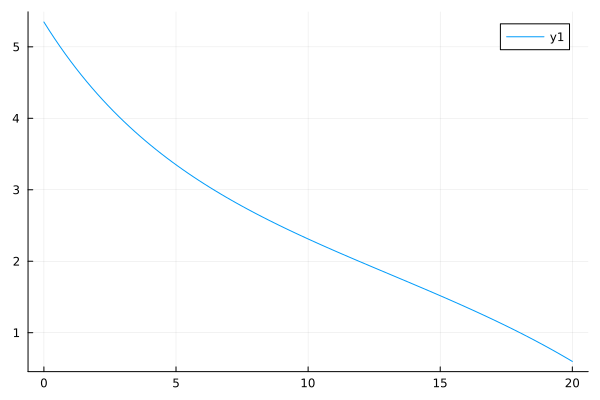

In [35]:
using Plots
plot(xy)

In [36]:
openPostProcessor()

-------------------------------------------------------
Version       : 4.15.0-git
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 19700101
Build host    : amdci7.julia.csail.mit.edu
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blossom Cairo DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack LinuxJoystick MathEx[contrib] Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.8
OCC version   : 7.9.2
Packaged by   : root
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------
